In [14]:
import pandas as pd

In [15]:
# Additional imports for analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
sns.set(style="whitegrid")

In [16]:
# Load data
df = pd.read_csv('Walmart_Store_sales.csv', parse_dates=['Date'])
print('Rows, cols:', df.shape)
df.head()

Rows, cols: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,12-02-2010,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,19-02-2010,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,26-02-2010,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,05-03-2010,"1,554,806.68",0,46.50,2.62,211.35,8.11


In [17]:
# Compute total Weekly_Sales per store and show the max
store_totals = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
#print(store_totals)
max_store = int(store_totals.index[0])
max_total = float(store_totals.iloc[0])
print(f'Store with maximum total sales: {max_store} — Total: {max_total:.2f}')
#store_totals.head(10)

Store with maximum total sales: 20 — Total: 301397792.46


In [18]:
# Compute per-store mean, std, coefficient of variation (std/mean) and mean-to-std
stats = df.groupby('Store')['Weekly_Sales'].agg(['mean','std']).rename(columns={'mean':'Mean','std':'Std'})
stats['CV'] = stats['Std'] / stats['Mean']
stats['Mean_to_Std'] = stats['Mean'] / stats['Std']
# Which store has maximum std
stats_sorted_std = stats.sort_values('Std', ascending=False)
max_std_store = int(stats_sorted_std.index[0])
print(f"Store with maximum std (most variable sales): {max_std_store} — Std: {stats_sorted_std.loc[max_std_store,'Std']:.2f}, Mean: {stats_sorted_std.loc[max_std_store,'Mean']:.2f}, CV: {stats_sorted_std.loc[max_std_store,'CV']:.4f}")
# Show top 10 by std
stats_sorted_std.head(10)

Store with maximum std (most variable sales): 14 — Std: 317569.95, Mean: 2020978.40, CV: 0.1571


,Mean,Std,CV,Mean_to_Std
Store,,,,
14,"2,020,978.40","317,569.95",0.16,6.36
10,"1,899,424.57","302,262.06",0.16,6.28
20,"2,107,676.87","275,900.56",0.13,7.64
4,"2,094,712.96","266,201.44",0.13,7.87
13,"2,003,620.31","265,507.00",0.13,7.55
23,"1,389,864.46","249,788.04",0.18,5.56
27,"1,775,216.20","239,930.14",0.14,7.40
2,"1,925,751.34","237,683.69",0.12,8.10
39,"1,450,668.13","217,466.45",0.15,6.67


In [20]:
# Quarterly growth: Q2 2012 -> Q3 2012 per store
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
# Ensure Date is datetime and extract Year/Month (if not already present)
# Coerce to datetime if needed, show invalid counts for debugging
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print('Date dtype after conversion:', df['Date'].dtype)
nat_count = df['Date'].isna().sum()
print('Invalid / NaT date count:', nat_count)
if nat_count > 0:
    display(df[df['Date'].isna()].head())
# Now continue with quarter aggregation (drop rows with NaT dates to be safe)
df = df.dropna(subset=['Date']).copy()
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df2012 = df[df['Year'] == 2012].copy()
# Define quarters: Q2 = Apr(4),May(5),Jun(6); Q3 = Jul(7),Aug(8),Sep(9)
q2_mask = df2012['Month'].isin([4,5,6])
q3_mask = df2012['Month'].isin([7,8,9])
q2_totals = df2012[q2_mask].groupby('Store')['Weekly_Sales'].sum().rename('Q2_2012')
q3_totals = df2012[q3_mask].groupby('Store')['Weekly_Sales'].sum().rename('Q3_2012')
growth_df = pd.concat([q2_totals, q3_totals], axis=1).fillna(0)
# Compute growth; avoid division by zero by using NA where Q2==0
growth_df['Growth'] = (growth_df['Q3_2012'] - growth_df['Q2_2012']) / growth_df['Q2_2012'].replace(0, pd.NA)
growth_df = growth_df.sort_values('Growth', ascending=False)
# Show top 10 growers by growth
print('Top 10 stores by Q3 vs Q2 growth (2012):')
display(growth_df.head(10))
# Summary counts and lists
positive = growth_df[growth_df['Growth'] > 0]
print(f'Number of stores with positive growth: {positive.shape[0]}')
print('\nStores with growth > 10%:')
display(growth_df[growth_df['Growth'] > 0.10])
# Return the growth_df for further inspection if needed
growth_df

Date dtype after conversion: datetime64[ns]
Invalid / NaT date count: 3870


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
2,1,NaT,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,NaT,"1,409,727.59",0,46.63,2.56,211.32,8.11
6,1,NaT,"1,472,515.79",0,54.58,2.72,211.22,8.11
7,1,NaT,"1,404,429.92",0,51.45,2.73,211.02,8.11
10,1,NaT,"1,466,058.28",0,66.32,2.81,210.49,7.81


Top 10 stores by Q3 vs Q2 growth (2012):


,Q2_2012,Q3_2012,Growth
Store,,,
35,"4,155,582.19","2,654,599.71",-0.36
33,"1,352,602.83","859,857.83",-0.36
16,"2,607,204.97","1,636,709.13",-0.37
14,"9,734,242.62","6,024,967.53",-0.38
42,"3,109,823.99","1,919,892.98",-0.38
28,"7,440,072.28","4,591,145.74",-0.38
12,"5,142,747.75","3,154,586.08",-0.39
13,"10,360,261.14","6,334,679.86",-0.39
21,"3,444,566.26","2,105,807.41",-0.39


Number of stores with positive growth: 0

Stores with growth > 10%:


,Q2_2012,Q3_2012,Growth
Store,,,


,Q2_2012,Q3_2012,Growth
Store,,,
35,"4,155,582.19","2,654,599.71",-0.36
33,"1,352,602.83","859,857.83",-0.36
16,"2,607,204.97","1,636,709.13",-0.37
14,"9,734,242.62","6,024,967.53",-0.38
42,"3,109,823.99","1,919,892.98",-0.38
28,"7,440,072.28","4,591,145.74",-0.38
12,"5,142,747.75","3,154,586.08",-0.39
13,"10,360,261.14","6,334,679.86",-0.39
21,"3,444,566.26","2,105,807.41",-0.39


In [21]:
# Compare holiday-week average sales vs non-holiday mean (all stores combined)
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
# Define holiday dates (dates represent the week including the holiday)
holiday_map = {
    'Super_Bowl': [pd.to_datetime('2010-02-12'), pd.to_datetime('2011-02-11'), pd.to_datetime('2012-02-10')],
    'Labour_Day': [pd.to_datetime('2010-09-10'), pd.to_datetime('2011-09-09'), pd.to_datetime('2012-09-07')],
    'Thanksgiving': [pd.to_datetime('2010-11-26'), pd.to_datetime('2011-11-25'), pd.to_datetime('2012-11-23')],
    'Christmas': [pd.to_datetime('2010-12-31'), pd.to_datetime('2011-12-30'), pd.to_datetime('2012-12-28')],
}
# Ensure Date is datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Drop rows with invalid dates to be safe
df = df.dropna(subset=['Date']).copy()
# Map holiday name to rows; default = 'Non-Holiday'
df['Holiday_Name'] = 'Non-Holiday'
for name, dates in holiday_map.items():
    # match exact date (week start) — convert to date for safe comparison
    match_dates = set([d.date() for d in dates])
    mask = df['Date'].dt.date.isin(match_dates)
    df.loc[mask, 'Holiday_Name'] = name
# Compute overall mean for non-holiday weeks across all stores
non_holiday_mean = df[df['Holiday_Name']=='Non-Holiday']['Weekly_Sales'].mean()
print(f'Overall mean Weekly_Sales (non-holiday weeks, all stores): {non_holiday_mean:.2f}')
# Compute mean Weekly_Sales for each holiday name (all stores combined)
holiday_avgs = df[df['Holiday_Name']!='Non-Holiday'].groupby('Holiday_Name')['Weekly_Sales'].mean().rename('Holiday_Mean').reset_index()
# Compare to non-holiday mean
holiday_avgs['HigherThanNonHoliday'] = holiday_avgs['Holiday_Mean'] > non_holiday_mean
holiday_avgs['Diff'] = holiday_avgs['Holiday_Mean'] - non_holiday_mean
# Show results
display(holiday_avgs.sort_values('Diff', ascending=False))
# List holidays that have higher sales than non-holiday mean
higher = holiday_avgs[holiday_avgs['HigherThanNonHoliday']]
if higher.empty:
    print('No holiday in the dataset has higher average weekly sales than the non-holiday mean (all stores).')
else:
    print('Holidays with higher average weekly sales than non-holiday mean:')
    display(higher)

Overall mean Weekly_Sales (non-holiday weeks, all stores): 1060241.40


,Holiday_Name,Holiday_Mean,HigherThanNonHoliday,Diff
0,Labour_Day,"1,039,182.83",False,"-21,058.57"


No holiday in the dataset has higher average weekly sales than the non-holiday mean (all stores).


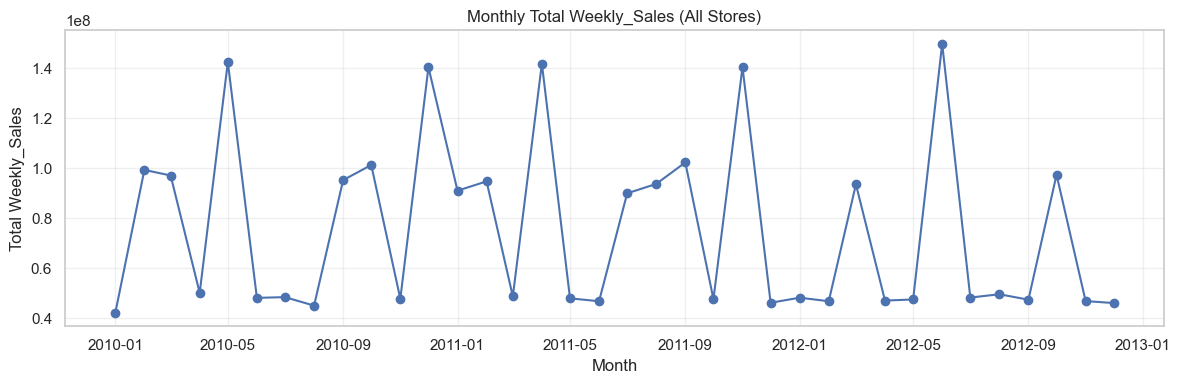

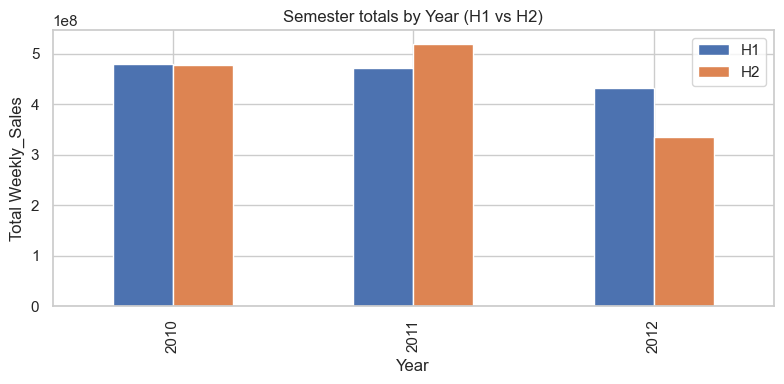


Top 6 months by total sales (all years combined):
YearMonth   Weekly_Sales
  2012-06 149,710,759.70
  2010-05 142,404,192.69
  2011-04 141,789,259.16
  2011-11 140,437,736.94
  2010-12 140,386,874.97
  2011-09 102,324,375.23

Recent monthly % changes (last 8 months):
YearMonth   Weekly_Sales  MoM_Pct
  2012-05  47,566,639.31     0.94
  2012-06 149,710,759.70   214.74
  2012-07  48,330,059.31   -67.72
  2012-08  49,651,171.78     2.73
  2012-09  47,480,454.11    -4.37
  2012-10  97,412,858.96   105.16
  2012-11  46,925,878.99   -51.83
  2012-12  46,128,514.25    -1.70

Semester totals and H2 vs H1 change (%):
                 H1             H2  H2_vs_H1_pct
Year                                            
2010 479,482,212.05 478,385,627.48         -0.23
2011 471,243,369.05 520,415,622.75         10.43
2012 433,115,789.28 335,928,937.40        -22.44

Insights:
- Peak month overall: 2012-06 with total 149710759.70.
- Year 2010: H1 (479482212.05) > H2 (478385627.48) — H1 stronger this ye

(Month            1             2             3              4              5   \
 Year                                                                            
 2010  42,239,875.87 99,341,315.76 97,103,285.49  50,188,543.12 142,404,192.69   
 2011  91,037,510.69 94,767,179.76 48,771,994.18 141,789,259.16  48,015,466.97   
 2012  48,281,649.72 46,861,034.97 93,571,507.65  47,124,197.93  47,566,639.31   
 
 Month             6             7             8              9   \
 Year                                                              
 2010   48,204,999.12 48,503,243.52 45,102,974.23  95,264,819.81   
 2011   46,861,958.29 89,987,476.13 93,746,730.58 102,324,375.23   
 2012  149,710,759.70 48,330,059.31 49,651,171.78  47,480,454.11   
 
 Month             10             11             12  
 Year                                                
 2010  101,301,168.23  47,826,546.72 140,386,874.97  
 2011   47,669,734.66 140,437,736.94  46,249,569.21  
 2012   97,412,858.96  46,925,

In [22]:
# Monthly and Semester Sales View (overall and per-year)
import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:,.2f}'.format

# Ensure Date is datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['Date']).copy()

# Add Year, Month, Semester
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

def semester_of(month):
    return 1 if month <= 6 else 2

df['Semester'] = df['Month'].apply(semester_of)

# Monthly totals (time series)
monthly_ts = df.groupby('YearMonth')['Weekly_Sales'].sum().reset_index()
monthly_ts['YearMonth_dt'] = pd.to_datetime(monthly_ts['YearMonth'])

# Pivot table: rows=Year, cols=Month
monthly_pivot = df.groupby(['Year','Month'])['Weekly_Sales'].sum().unstack(fill_value=0)

# Semester totals per year
semester_totals = df.groupby(['Year','Semester'])['Weekly_Sales'].sum().unstack(fill_value=0)
semester_totals.columns = [f'H{int(c)}' for c in semester_totals.columns]

# Simple plots
plt.figure(figsize=(12,4))
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['Weekly_Sales'], marker='o')
plt.title('Monthly Total Weekly_Sales (All Stores)')
plt.xlabel('Month')
plt.ylabel('Total Weekly_Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bar chart for semester totals
semester_totals.plot(kind='bar', figsize=(8,4), title='Semester totals by Year (H1 vs H2)')
plt.ylabel('Total Weekly_Sales')
plt.tight_layout()
plt.show()

# Key summary numbers and insights
# Top months overall
top_months = monthly_ts.sort_values('Weekly_Sales', ascending=False).head(6)

# Month-over-month percentage change
monthly_ts = monthly_ts.sort_values('YearMonth_dt')
monthly_ts['MoM_Pct'] = monthly_ts['Weekly_Sales'].pct_change() * 100

# Semester growth year-over-year (H2 vs H1 within same year)
semester_totals['H2_vs_H1_pct'] = (semester_totals.get('H2',0) - semester_totals.get('H1',0)) / semester_totals.get('H1', pd.NA) * 100

print('\nTop 6 months by total sales (all years combined):')
print(top_months[['YearMonth','Weekly_Sales']].to_string(index=False))

print('\nRecent monthly % changes (last 8 months):')
print(monthly_ts[['YearMonth','Weekly_Sales','MoM_Pct']].tail(8).to_string(index=False))

print('\nSemester totals and H2 vs H1 change (%):')
print(semester_totals[['H1','H2','H2_vs_H1_pct']].to_string())

# Insights (automatically generated):
insights = []
# 1. Peak months
peak_month = top_months.iloc[0]
insights.append(f"Peak month overall: {peak_month['YearMonth']} with total {peak_month['Weekly_Sales']:.2f}.")
# 2. Semester dominance
for yr in semester_totals.index:
    h1 = semester_totals.loc[yr,'H1'] if 'H1' in semester_totals.columns else 0
    h2 = semester_totals.loc[yr,'H2'] if 'H2' in semester_totals.columns else 0
    if pd.notna(h1) and pd.notna(h2):
        if h2 > h1:
            insights.append(f"Year {yr}: H2 ({h2:.2f}) > H1 ({h1:.2f}) — H2 stronger this year.")
        elif h1 > h2:
            insights.append(f"Year {yr}: H1 ({h1:.2f}) > H2 ({h2:.2f}) — H1 stronger this year.")

# 3. Recent trend
recent = monthly_ts.tail(6)
avg_recent_pct = recent['MoM_Pct'].mean()
insights.append(f"Recent 6-month average MoM change: {avg_recent_pct:.2f}%.")

print('\nInsights:')
for it in insights:
    print('-', it)

# Provide dataframes for further inspection
monthly_pivot, semester_totals, monthly_ts


Store 1: Train rows=53, Test rows=4
LinearRegression RMSE: 134384.61
RandomForest RMSE:   115756.89
LinearRegression RMSE: 134384.61
RandomForest RMSE:   115756.89


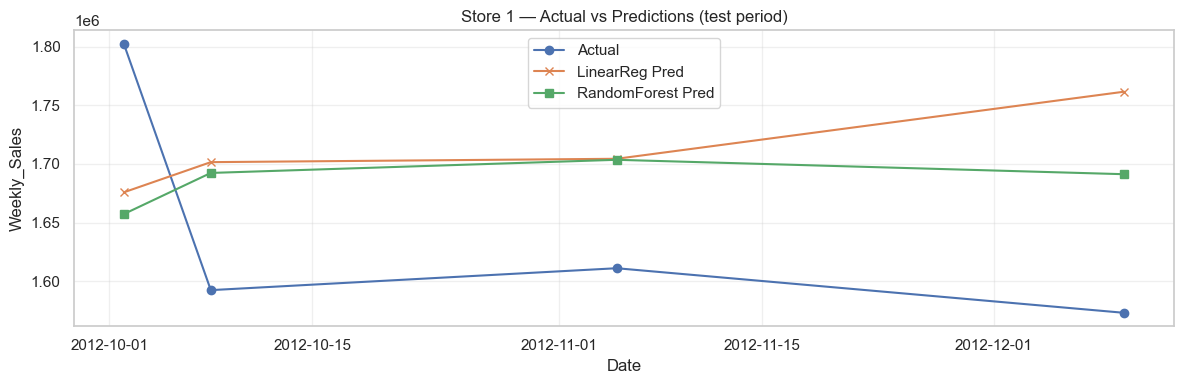


RandomForest feature importances:


CPI            0.40
Fuel_Price     0.15
Temperature    0.12
WeekOfYear     0.08
lag_1          0.06
roll_4         0.05
lag_2          0.05
Unemployment   0.04
Month          0.03
Holiday_Flag   0.00
dtype: float64


Saved test-period predictions to: store_1_predictions.csv

Next steps:
- Add additional lag features (lag 3,4, seasonal lags).
- Try time-series models (SARIMA, Prophet) or store-level ensembles.
- Hyperparameter-tune the RandomForest and consider stacking.


In [24]:
# Store 1 — Forecasting models (baseline LinearRegression + RandomForest)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

pd.options.display.float_format = '{:,.2f}'.format

# Prepare store-level data
store_id = 1
store_df = df[df['Store'] == store_id].sort_values('Date').copy()

# Ensure Date is datetime
if not pd.api.types.is_datetime64_any_dtype(store_df['Date']):
    store_df['Date'] = pd.to_datetime(store_df['Date'], errors='coerce')
store_df = store_df.dropna(subset=['Date']).reset_index(drop=True)

# Feature engineering: date parts and lags
store_df['Month'] = store_df['Date'].dt.month
store_df['WeekOfYear'] = store_df['Date'].dt.isocalendar().week.astype(int)

# Create lag features and rolling means
store_df['lag_1'] = store_df['Weekly_Sales'].shift(1)
store_df['lag_2'] = store_df['Weekly_Sales'].shift(2)
store_df['roll_4'] = store_df['Weekly_Sales'].shift(1).rolling(window=4).mean().reset_index(drop=True)

# Fill small number of NaNs with median (simple approach)
store_df['lag_1'] = store_df['lag_1'].fillna(store_df['Weekly_Sales'].median())
store_df['lag_2'] = store_df['lag_2'].fillna(store_df['Weekly_Sales'].median())
store_df['roll_4'] = store_df['roll_4'].fillna(store_df['Weekly_Sales'].median())

# Features and target
features = ['Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag','Month','WeekOfYear','lag_1','lag_2','roll_4']
# Keep only columns present in dataset (safety)
features = [f for f in features if f in store_df.columns]
X = store_df[features]
y = store_df['Weekly_Sales'].values

# Time-based train/test split: last 12 weeks as test
cut_date = store_df['Date'].max() - pd.Timedelta(weeks=12)
train_mask = store_df['Date'] <= cut_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Store {store_id}: Train rows={X_train.shape[0]}, Test rows={X_test.shape[0]}")

# 1) Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# 2) Random Forest baseline
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'LinearRegression RMSE: {rmse_lr:.2f}')
print(f'RandomForest RMSE:   {rmse_rf:.2f}')

# Comparison dataframe for test period
results = store_df.loc[~train_mask, ['Date','Weekly_Sales','Holiday_Flag']].copy()
results['Pred_LR'] = y_pred_lr
results['Pred_RF'] = y_pred_rf

# Plot actual vs predictions
plt.figure(figsize=(12,4))
plt.plot(results['Date'], results['Weekly_Sales'], label='Actual', marker='o')
plt.plot(results['Date'], results['Pred_LR'], label='LinearReg Pred', marker='x')
plt.plot(results['Date'], results['Pred_RF'], label='RandomForest Pred', marker='s')
plt.title(f'Store {store_id} — Actual vs Predictions (test period)')
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance for RandomForest (if available)
if hasattr(rf, 'feature_importances_'):
    fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print('\nRandomForest feature importances:')
    display(fi)

# Save results to CSV for inspection (optional)
results.to_csv(f'store_{store_id}_predictions.csv', index=False)

print('\nSaved test-period predictions to:', f'store_{store_id}_predictions.csv')

# Quick next steps suggestions printed
print('\nNext steps:')
print('- Add additional lag features (lag 3,4, seasonal lags).')
print('- Try time-series models (SARIMA, Prophet) or store-level ensembles.')
print('- Hyperparameter-tune the RandomForest and consider stacking.')

In [26]:
# Linear Regression with restructured date index and inference for Store 1 (robust checks)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
pd.options.display.float_format = '{:,.2f}'.format

# Prepare Store 1 data (ensure Date is datetime)
store_id = 1
store_df = df[df['Store'] == store_id].sort_values('Date').copy()
if not pd.api.types.is_datetime64_any_dtype(store_df['Date']):
    store_df['Date'] = pd.to_datetime(store_df['Date'], errors='coerce')
store_df = store_df.dropna(subset=['Date']).reset_index(drop=True)

# Create week-based DateIndex where earliest date -> 1
min_date = store_df['Date'].min()
store_df['WeekIdx'] = ((store_df['Date'] - min_date).dt.days // 7).astype(int) + 1
print(f"Earliest date: {min_date.date()}, WeekIdx starts at {store_df['WeekIdx'].min()}")

# Select features for the linear model: WeekIdx + economic indicators
candidate_features = ['WeekIdx','CPI','Unemployment','Fuel_Price']
features = [f for f in candidate_features if f in store_df.columns]
if not features:
    raise RuntimeError(f'None of candidate features present in data: {candidate_features}')
print('Using features:', features)

# Make sure features are numeric and drop rows with NA in features or target
store_df[features] = store_df[features].apply(pd.to_numeric, errors='coerce')
train_df = store_df.dropna(subset=features + ['Weekly_Sales']).copy()
print(f'Rows after dropping NA in features+target: {train_df.shape[0]}')

# Train/test split (time-based): last 12 weeks as test
cut_date = train_df['Date'].max() - pd.Timedelta(weeks=12)
train_mask = train_df['Date'] <= cut_date
X_train = train_df.loc[train_mask, features]
X_test = train_df.loc[~train_mask, features]
y_train = train_df.loc[train_mask, 'Weekly_Sales']
y_test = train_df.loc[~train_mask, 'Weekly_Sales']
print(f"Linear model data: Train={X_train.shape[0]} rows, Test={X_test.shape[0]} rows")

# Check we have enough rows
if X_train.shape[0] < 5 or X_test.shape[0] < 2:
    print('Warning: small train/test sizes — results may be unreliable. Skipping model fit if insufficient data.')
    # still attempt if at least 2 train rows and 1 test row
    if X_train.shape[0] < 2 or X_test.shape[0] < 1:
        raise RuntimeError('Not enough data to fit model. Need at least 2 train rows and 1 test row.')

# Fit sklearn LinearRegression for RMSE evaluation
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f'LinearRegression RMSE on test set: {rmse_lr:.2f}')

# Fit statsmodels OLS on training data for inference (coefficients, p-values)
try:
    X_train_sm = sm.add_constant(X_train)
    ols_model = sm.OLS(y_train, X_train_sm).fit()
    print('\nStatsmodels OLS summary (training data):')
    print(ols_model.summary())

    # Coefficients interpretation: show coef, std err, p>|t|
    coefs = pd.DataFrame({ 'coef': ols_model.params, 'std_err': ols_model.bse, 'p_value': ols_model.pvalues })
    display(coefs)
except Exception as e:
    print('Statsmodels OLS failed:', str(e))
    coefs = pd.DataFrame()

# Quick scatter plots to visualize relationships (only for numeric features)
for col in features[1:]:
    if col in train_df.columns:
        plt.figure(figsize=(6,3))
        plt.scatter(train_df[col], train_df['Weekly_Sales'], alpha=0.6)
        plt.title(f'Store {store_id}: Weekly_Sales vs {col}')
        plt.xlabel(col)
        plt.ylabel('Weekly_Sales')
        plt.tight_layout()
        plt.show()

# Short hypothesis guidance based on p-values (if available)
print('\nHypothesis guidance (using p-value threshold 0.05):')
if not coefs.empty:
    for feat in ['WeekIdx','CPI','Unemployment','Fuel_Price']:
        if feat in coefs.index:
            p = coefs.loc[feat,'p_value']
            coef = coefs.loc[feat,'coef']
            if p < 0.05:
                direction = 'positive' if coef > 0 else 'negative'
                print(f"- {feat}: significant (p={p:.3f}); estimated effect is {direction} (coef={coef:.4f}).")
            else:
                print(f"- {feat}: NOT significant (p={p:.3f}); cannot reliably conclude an effect on sales.")
        else:
            print(f"- {feat}: not in model.")
else:
    print('No coefficient table available to assess significance.')

# Save OLS results to CSV for reference if available
if not coefs.empty:
    coefs.to_csv(f'store_{store_id}_linear_coefs.csv')
    print('\nSaved coefficients to', f'store_{store_id}_linear_coefs.csv')
else:
    print('\nNo coefficients saved (OLS not available).')

ModuleNotFoundError: No module named 'statsmodels'